[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/IntroduccionAstronomiaPractica/blob/main/RefraccionAtmosferica/RefraccionAtmosferica.ipynb)

# Refracción atmosférica: desarrollo ampliado de la actividad

**Curso:** Introducción a la Astronomía Práctica  
**Tema:** Efecto de la atmósfera en la posición y forma aparente de objetos celestes

Este cuaderno desarrolla de forma más extensa la actividad de la carpeta **RefraccionAtmosferica**.  
Además de los cálculos numéricos, se incluye una discusión física más detallada, interpretación observacional y visualizaciones para ver de manera aproximada el **achatamiento del disco solar/lunar** cuando el astro está cerca del horizonte.

La meta es conectar tres niveles:  
1. el modelo matemático de refracción,  
2. la estimación cuantitativa en datos tipo observación,  
3. la apariencia real del disco en el cielo.


## 1. Contexto físico

La atmósfera terrestre es un medio estratificado: su densidad, presión y temperatura cambian con la altura. En términos ópticos, esto implica que el índice de refracción del aire no es constante. Por esa razón, la luz de un astro no sigue una recta perfecta al atravesar la atmósfera, sino una trayectoria curva que se desvía gradualmente hacia las capas más densas.

Consecuencias observacionales principales:

- Un objeto cercano al horizonte se observa **más alto** que su posición geométrica real.
- En objetos extensos (Sol/Luna), el borde inferior atraviesa una porción atmosférica más densa que el borde superior y sufre mayor desviación: aparece un **achatamiento vertical**.
- El amanecer ocurre unos minutos antes y el atardecer unos minutos después respecto al caso sin atmósfera.

En astronomía de posición, estos efectos pueden introducir errores de varios minutos de arco si no se aplican correcciones.


## 2. Objetivos

1. Cuantificar cómo cambia la razón de aspecto del disco $W/h_v$ con la altura angular $h$.
2. Comparar alturas aparentes y geométricas para estimar el corrimiento por refracción.
3. Evaluar cómo cambian los resultados al modificar condiciones locales de presión y temperatura.
4. Visualizar gráficamente la deformación para que el achatamiento sea evidente de forma cualitativa y cuantitativa.
5. Discutir implicaciones para observación, astrometría y reducción de datos.


## 3. Ecuación de trabajo

Usaremos la aproximación empírica indicada en la guía para la refracción atmosférica en minutos de arco:

$$R\,[\text{arcmin}] = \cot \left( h[^\circ] + \frac{7.31}{h[^\circ] + 4.4} \right) \left( \frac{P}{101\,\text{kPa}} \right) \left( \frac{273}{273 + T} \right)$$

donde:

- $h$: altura angular en grados,
- $P$: presión atmosférica en kPa,
- $T$: temperatura en $^\circ\mathrm{C}$.

La conversión a grados se hace con:

$$
R_{\text{deg}} = \frac{R_{\text{arcmin}}}{60}
$$

Por tanto, una estimación de la altura aparente es:

$$
h_{\text{aparente}} \approx h_{\text{geom}} + R_{\text{deg}}
$$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('classic')


def refraccion_arcmin(h_deg, P_kpa=84.0, T_c=18.0):
    """Aproximación de refracción atmosférica (arcmin)."""
    h = np.asarray(h_deg, dtype=float)
    arg_deg = h + 7.31/(h + 4.4)
    R = 1/np.tan(np.deg2rad(arg_deg))
    R *= (P_kpa/101.0) * (273.0/(273.0 + T_c))
    return R


## 4. Experimento 0: deformación del disco (datos realistas)

Se simula una secuencia fotográfica de puesta del Sol con filtro solar. Los diámetros en píxeles son coherentes con una misma distancia focal: el diámetro horizontal cambia poco, mientras el vertical aumenta con la altura al disminuir la refracción diferencial.

**Condiciones de observación supuestas (realistas):**

- Ciudad: Medellín ($\sim 1500\,\mathrm{m}$ s.n.m.)
- Temperatura ambiente: $18\,^\circ\mathrm{C}$
- Presión local: $84\,\mathrm{kPa}$
- Intervalo temporal entre imágenes: 4 a 6 minutos

En esta parte, el indicador clave es la razón de aspecto $W/h_v$. Si $W/h_v>1$, el disco está comprimido en vertical.


In [2]:
# Tabla 0: mediciones del disco en pixeles
altura_deg = np.array([1.2, 2.5, 4.0, 5.8, 7.6, 9.5, 12.0, 15.0, 18.5])
ancho_px   = np.array([1888, 1887, 1889, 1886, 1888, 1887, 1888, 1887, 1888])
alto_px    = np.array([1548, 1623, 1698, 1750, 1789, 1814, 1846, 1868, 1881])

ratio = ancho_px / alto_px

tabla0 = pd.DataFrame({
    'Hora local': ['17:58','18:03','18:08','18:13','18:18','18:24','18:30','18:37','18:45'],
    'Altura h (deg)': altura_deg,
    'Ancho W (px)': ancho_px,
    'Alto hv (px)': alto_px,
    'W/hv': np.round(ratio, 3)
})

tabla0


,Hora local,Altura h (deg),Ancho W (px),Alto hv (px),W/hv
0,17:58,1.2,1888,1548,1.220
1,18:03,2.5,1887,1623,1.163
2,18:08,4.0,1889,1698,1.112
3,18:13,5.8,1886,1750,1.078
4,18:18,7.6,1888,1789,1.055
5,18:24,9.5,1887,1814,1.040
6,18:30,12.0,1888,1846,1.023
7,18:37,15.0,1887,1868,1.010
8,18:45,18.5,1888,1881,1.004


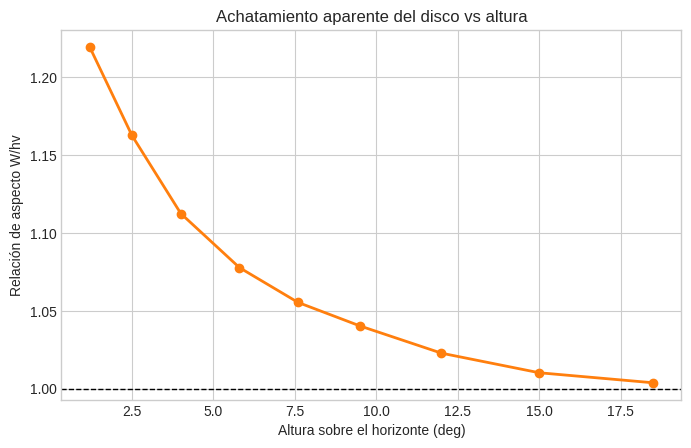

In [3]:
fig, ax = plt.subplots(figsize=(8,4.8))
ax.plot(altura_deg, ratio, 'o-', color='tab:orange', lw=2)
ax.axhline(1.0, color='k', ls='--', lw=1)
ax.set_xlabel('Altura sobre el horizonte (deg)')
ax.set_ylabel('Relación de aspecto W/hv')
ax.set_title('Achatamiento aparente del disco vs altura')
plt.show()


### Interpretación del Experimento 0

- Cerca del horizonte ($h\approx 1$ a $3^\circ$), la razón $W/h_v$ es claramente mayor que 1; esto confirma compresión vertical apreciable.
- Al aumentar la altura, $W/h_v \to 1$, lo que indica recuperación progresiva de una forma casi circular.
- En esta serie, la deformación se vuelve poco perceptible para $h\gtrsim 12^\circ$, donde la razón se acerca a valores de 1.02 o menores.


## 4.1 Visualización geométrica del achatamiento

Para ver el efecto de forma directa, representamos discos normalizados donde el ancho horizontal se fija en 1 y la altura vertical se ajusta según la razón observada $W/h_v$.

Si definimos $r=W/h_v$, entonces la altura relativa del disco es:

$$

\frac{h_v}{W}=
\frac{1}{r}.
$$

Así, valores grandes de $r$ producen elipses más achatadas en vertical.


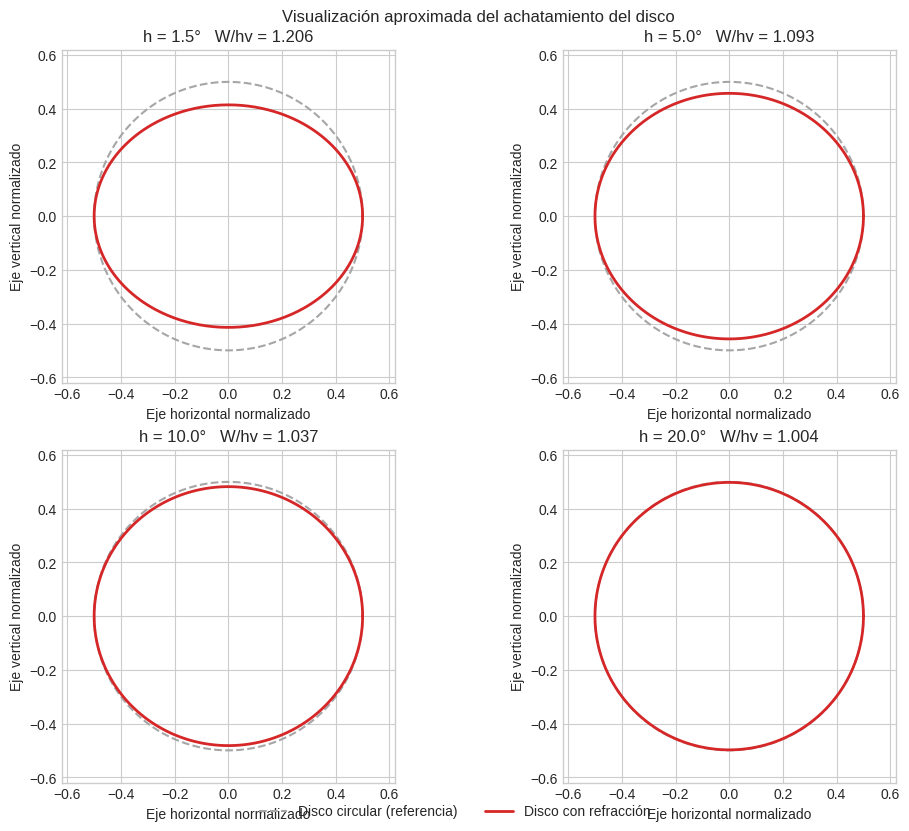

In [4]:
# Elipses aproximadas del disco para distintas alturas
alturas_demo = np.array([1.5, 5.0, 10.0, 20.0])
ratio_demo = np.interp(alturas_demo, altura_deg, ratio)

t = np.linspace(0, 2*np.pi, 500)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, h_i, r_i in zip(axes.ravel(), alturas_demo, ratio_demo):
    a = 0.5                 # semieje horizontal fijo
    b = 0.5 / r_i           # semieje vertical a partir de W/hv

    x = a*np.cos(t)
    y = b*np.sin(t)

    x_ref = a*np.cos(t)
    y_ref = a*np.sin(t)

    ax.plot(x_ref, y_ref, '--', color='0.65', lw=1.5, label='Disco circular (referencia)')
    ax.plot(x, y, color='tab:red', lw=2, label='Disco con refracción')
    ax.set_title(f'h = {h_i:.1f}°   W/hv = {r_i:.3f}')
    ax.set_aspect('equal')
    ax.set_xlim(-0.62, 0.62)
    ax.set_ylim(-0.62, 0.62)
    ax.set_xlabel('Eje horizontal normalizado')
    ax.set_ylabel('Eje vertical normalizado')

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False)
fig.suptitle('Visualización aproximada del achatamiento del disco', y=1.02)
plt.show()


### Interpretación visual

En los paneles anteriores se aprecia que cerca del horizonte la elipse comprimida difiere claramente del círculo de referencia. Al subir en altura, la diferencia disminuye y la figura tiende a circularse.

Esta visualización no pretende ser un trazado óptico exacto capa por capa, sino una representación aproximada y útil del efecto observado en fotografía astronómica.


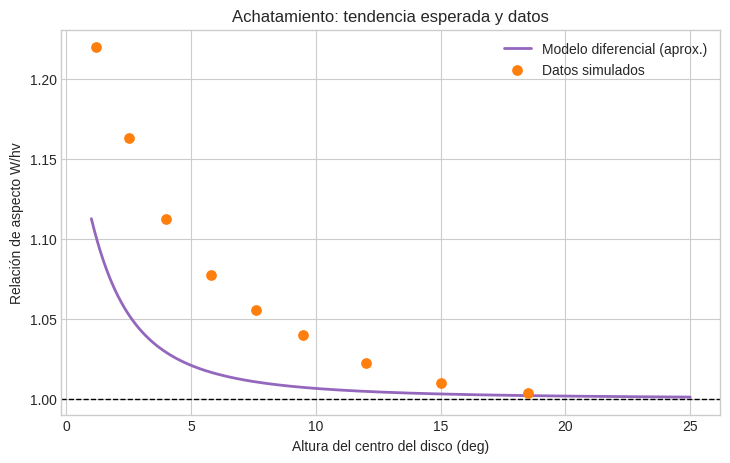

In [5]:
# Estimación simple del achatamiento a partir de refracción diferencial (borde inferior vs superior)
diametro_angular = 0.53  # deg, valor típico Sol/Luna
h_centro = np.linspace(1.0, 25.0, 200)

h_inf = np.clip(h_centro - diametro_angular/2, 0.1, None)
h_sup = h_centro + diametro_angular/2

R_inf = refraccion_arcmin(h_inf, P_kpa=84.0, T_c=18.0)/60.0
R_sup = refraccion_arcmin(h_sup, P_kpa=84.0, T_c=18.0)/60.0

diam_vertical_ap = diametro_angular + (R_sup - R_inf)
ratio_modelo = diametro_angular / diam_vertical_ap

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.plot(h_centro, ratio_modelo, color='tab:purple', lw=2, label='Modelo diferencial (aprox.)')
ax.scatter(altura_deg, ratio, color='tab:orange', s=45, zorder=3, label='Datos simulados')
ax.axhline(1.0, color='k', ls='--', lw=1)
ax.set_xlabel('Altura del centro del disco (deg)')
ax.set_ylabel('Relación de aspecto W/hv')
ax.set_title('Achatamiento: tendencia esperada y datos')
ax.legend()
plt.show()


## 5. Experimento 1: alturas aparentes vs reales con astroquery

En lugar de un ejemplo manual, aquí se usa **astroquery** para recuperar parámetros astrométricos reales desde SIMBAD y construir una serie temporal densa (cada 5 minutos) durante una noche específica. La comparación entre altura geométrica y altura aparente se hace con la ecuación de refracción de la guía, bajo condiciones realistas de Medellín.

**Fecha elegida:** noche del **22 al 23 de mayo de 2026** (UTC-5)  
**Lugar:** Medellín, Colombia (lat 6.2442° N, lon 75.5812° O, ~1495 m s.n.m.)  
**Condiciones locales:** $P=84\,\mathrm{kPa}$, $T=18\,^{\circ}\mathrm{C}$

La estrategia es:
1. Consultar astroquery para obtener RA/Dec, magnitud, tipo espectral y movimientos propios.
2. Propagar las coordenadas al 2026.
3. Calcular alturas geométricas desde Medellín.
4. Aplicar el modelo de refracción para estimar alturas aparentes.
5. Analizar el tramo de baja altura ($2^{\circ}$ a $25^{\circ}$), donde la refracción es más relevante.

### 5.1 Configuración del sitio y ventana temporal

Se fija el sitio de observación en Medellín y se define una malla temporal cada 5 minutos. Se trabaja en hora local (UTC-5) para que los gráficos sean interpretables, pero las conversiones a AltAz se hacen en UTC como recomienda Astropy.

In [6]:
!pip install astroquery astropy -q

In [7]:
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Distance
from astropy.time import Time
from astropy.utils import iers
import astropy.units as u
import matplotlib.dates as mdates

# Evitar descargas automáticas de IERS en entornos sin internet
iers.conf.auto_download = False

medellin = EarthLocation(lat=6.2442 * u.deg, lon=-75.5812 * u.deg, height=1495 * u.m)
P_kpa = 84.0
T_c = 18.0

fecha_base = "2026-05-22"
fecha_siguiente = "2026-05-23"

zona_horaria = "America/Bogota"

horas_tarde = pd.date_range(
    f"{fecha_base} 18:00", f"{fecha_base} 23:55", freq="5min", tz=zona_horaria
)
horas_manana = pd.date_range(
    f"{fecha_siguiente} 00:00", f"{fecha_siguiente} 06:00", freq="5min", tz=zona_horaria
)

horas_local = horas_tarde.union(horas_manana)
horas_utc = Time(horas_local.tz_convert("UTC").to_pydatetime())

momento_referencia = horas_utc[len(horas_utc) // 2]

### 5.2 Consulta a SIMBAD con astroquery

Se eligen dos estrellas brillantes visibles en mayo desde Medellín y que atraviesan alturas bajas durante la noche: **Spica** (α Vir) y **Antares** (α Sco). Con astroquery se recuperan parámetros astrométricos y fotométricos para documentar la fuente de datos.

In [8]:
estrellas_objetivo = ["Spica", "Antares"]


simbad = Simbad()


def cargar_catalogo_simbad(objetivos):
    try:
        simbad.add_votable_fields("pmra", "pmdec", "plx", "rvz_radvel", "V", "sp_type")
        catalogo = simbad.query_objects(objetivos)
    except Exception as exc:
        return None, exc
    return catalogo, None


catalogo, error_catalogo = cargar_catalogo_simbad(estrellas_objetivo)

if catalogo is None:
    print(f"SIMBAD no disponible ({error_catalogo}); usando datos locales.")
    catalogo_base = pd.DataFrame(
        {
            "main_id": estrellas_objetivo,
            "ra": ["13 25 11.6", "16 29 24.4"],
            "dec": ["-11 09 41", "-26 25 55"],
            "v": [0.98, 1.06],
            "sp_type": ["B1V", "M1.5Iab"],
            "pmra": [-42.36, -10.16],
            "pmdec": [-31.73, -23.21],
            "plx_value": [12.44, 5.41],
            "rvz_radvel": [1.0, 3.0],
        }
    )
else:
    catalogo_base = catalogo.to_pandas()
    catalogo_base.columns = [col.lower() for col in catalogo_base.columns]

    if "v" not in catalogo_base and "flux_v" in catalogo_base:
        catalogo_base["v"] = catalogo_base["flux_v"]
    if "plx_value" not in catalogo_base and "plx" in catalogo_base:
        catalogo_base["plx_value"] = catalogo_base["plx"]

    for col in ["pmra", "pmdec", "plx_value", "rvz_radvel"]:
        if col not in catalogo_base:
            catalogo_base[col] = np.nan


catalogo_pd = catalogo_base.copy()
catalogo_pd.insert(0, "Estrella", estrellas_objetivo)

# 1. Seleccionamos las columnas usando los nombres exactos que aparecen en tu índice
catalogo_pd = catalogo_pd[
    [
        "Estrella", "main_id", "ra", "dec", "v", "sp_type",
        "pmra", "pmdec", "plx_value", "rvz_radvel"
    ]
]

# 2. Renombramos las columnas (las llaves deben coincidir con los nombres anteriores)
catalogo_pd.rename(
    columns={
        "main_id": "ID SIMBAD",
        "ra": "RA (hms)",
        "dec": "Dec (dms)",
        "v": "V (mag)",
        "sp_type": "Tipo espectral",
        "pmra": "PM RA (mas/yr)",
        "pmdec": "PM Dec (mas/yr)",
        "plx_value": "Paralaje (mas)",
        "rvz_radvel": "Vel. radial (km/s)",
    },
    inplace=True
)

catalogo_pd


SIMBAD no disponible (Unable to access the capabilities endpoint at:
- https://simbad.cds.unistra.fr/simbad/sim-tap/capabilities: Connection failed (Possible causes: incorrect URL, DNS issue, or service is down)

This could mean:
1. The service URL is incorrect
2. The service is temporarily unavailable
3. The service doesn't support this protocol
4. If a 503 was encountered, retry after the suggested delay.
); usando datos locales.


,Estrella,ID SIMBAD,RA (hms),Dec (dms),V (mag),Tipo espectral,PM RA (mas/yr),PM Dec (mas/yr),Paralaje (mas),Vel. radial (km/s)
0,Spica,Spica,13 25 11.6,-11 09 41,0.98,B1V,-42.36,-31.73,12.44,1.0
1,Antares,Antares,16 29 24.4,-26 25 55,1.06,M1.5Iab,-10.16,-23.21,5.41,3.0


### 5.3 Coordenadas propagadas al 2026 y alturas geométricas

Con los movimientos propios se construyen coordenadas en el marco ICRS y se propagan al año 2026 (correcciones pequeñas pero profesionales). Luego se transforma a AltAz sin atmósfera para obtener alturas geométricas. La refracción se añade con la ecuación empírica de la guía.

In [9]:
def valor_valido(valor):
    if valor is None:
        return False
    try:
        if np.ma.is_masked(valor):
            return False
    except TypeError:
        pass
    try:
        if pd.isna(valor):
            return False
    except (TypeError, ValueError):
        pass
    return True


def valor_opcional(valor):
    if not valor_valido(valor):
        return None
    try:
        return float(valor)
    except (TypeError, ValueError):
        return None


def valor_coord(valor):
    """Valida valores de coordenadas y retorna None si son inválidos."""
    return valor if valor_valido(valor) else None


def unidad_ra(ra):
    if isinstance(ra, str):
        texto = ra.strip()
        if ":" in texto or " " in texto:
            return u.hourangle
        try:
            float(texto)
        except ValueError:
            return u.hourangle
        return u.deg
    return u.deg


def construir_coord(fila):
    """Construye SkyCoord desde datos de SIMBAD con movimientos propios."""
    pmra = valor_opcional(fila.get("pmra")) or 0.0
    pmdec = valor_opcional(fila.get("pmdec")) or 0.0

    ra = valor_coord(fila.get("ra"))
    dec = valor_coord(fila.get("dec"))
    if ra is None or dec is None:
        identificador = fila.get("main_id")
        raise ValueError(
            f"RA/Dec no disponibles para {identificador} en el catálogo SIMBAD."
        )

    ra_unit = unidad_ra(ra)

    kwargs = dict(
        ra=ra,
        dec=dec,
        unit=(ra_unit, u.deg),
        pm_ra_cosdec=pmra * u.mas / u.yr,
        pm_dec=pmdec * u.mas / u.yr,
        obstime=Time("J2000"),
    )

    paralaje = valor_opcional(fila.get("plx_value"))
    if paralaje and paralaje > 0:
        kwargs["distance"] = Distance(parallax=paralaje * u.mas)

    vel_radial = valor_opcional(fila.get("rvz_radvel"))
    if vel_radial:
        kwargs["radial_velocity"] = vel_radial * u.km / u.s

    return SkyCoord(**kwargs)

coords_j2000 = [construir_coord(fila) for _, fila in catalogo_base.iterrows()]
coords_2026 = [coord.apply_space_motion(new_obstime=momento_referencia) for coord in coords_j2000]

frame_geom = AltAz(obstime=horas_utc, location=medellin, pressure=0 * u.hPa)

series = []
for estrella, coord in zip(estrellas_objetivo, coords_2026):
    altaz = coord.transform_to(frame_geom)
    alt_geom = altaz.alt.deg

    ref_arcmin = np.where(
        alt_geom > 0.5,
        refraccion_arcmin(alt_geom, P_kpa=P_kpa, T_c=T_c),
        np.nan,
    )

    alt_aparente = alt_geom + ref_arcmin / 60.0

    serie = pd.DataFrame(
        {
            "Estrella": estrella,
            "Tiempo local": horas_local.tz_localize(None),
            "Altura real (deg)": alt_geom,
            "Altura aparente (deg)": alt_aparente,
            "Refracción (arcmin)": ref_arcmin,
            "Delta altura (deg)": alt_aparente - alt_geom,
        }
    )
    series.append(serie)

serie_total = pd.concat(series, ignore_index=True)
serie_total.head(8)


,Estrella,Tiempo local,Altura real (deg),Altura aparente (deg),Refracción (arcmin),Delta altura (deg)
0,Spica,2026-05-22 18:00:00,35.697489,35.715467,1.078658,0.017978
1,Spica,2026-05-22 18:05:00,36.875863,36.893087,1.033423,0.017224
2,Spica,2026-05-22 18:10:00,38.051068,38.067579,0.990679,0.016511
3,Spica,2026-05-22 18:15:00,39.222880,39.238717,0.950201,0.015837
4,Spica,2026-05-22 18:20:00,40.391058,40.406254,0.911792,0.015197
5,Spica,2026-05-22 18:25:00,41.555335,41.569923,0.875278,0.014588
6,Spica,2026-05-22 18:30:00,42.715420,42.729428,0.840502,0.014008
7,Spica,2026-05-22 18:35:00,43.870995,43.884450,0.807328,0.013455


### 5.4 Enfoque en baja altura y resumen estadístico

Para hacer comparable el efecto atmosférico, se selecciona el rango de alturas donde la refracción es más visible: entre $2^{\circ}$ y $25^{\circ}$. Se resume el número de datos útiles y los máximos corrimientos para cada estrella.

In [10]:
rango_bajo = (serie_total["Altura real (deg)"] >= 2) & (serie_total["Altura real (deg)"] <= 25)
serie_baja = serie_total[rango_bajo].copy()

resumen = serie_baja.groupby("Estrella").agg(
    puntos=("Altura real (deg)", "size"),
    altura_min=("Altura real (deg)", "min"),
    altura_max=("Altura real (deg)", "max"),
    refraccion_max=("Refracción (arcmin)", "max"),
    refraccion_mediana=("Refracción (arcmin)", "median"),
    delta_max=("Delta altura (deg)", "max"),
)

resumen

,puntos,altura_min,altura_max,refraccion_max,refraccion_mediana,delta_max
Estrella,,,,,,
Antares,41,2.571463,24.264491,12.332763,3.134464,0.205546
Spica,19,2.455244,24.275418,12.678421,3.172296,0.211307


In [11]:
idx_max = serie_baja.groupby("Estrella")["Refracción (arcmin)"].idxmax()
maximos = serie_baja.loc[
    idx_max,
    ["Estrella", "Tiempo local", "Altura real (deg)", "Refracción (arcmin)", "Delta altura (deg)"],
]

maximos

,Estrella,Tiempo local,Altura real (deg),Refracción (arcmin),Delta altura (deg)
156,Antares,2026-05-22 18:55:00,2.571463,12.332763,0.205546
110,Spica,2026-05-23 03:10:00,2.455244,12.678421,0.211307


### 5.5 Gráficos de diagnóstico

Los siguientes gráficos muestran: (1) alturas geométricas y aparentes a lo largo de la noche, (2) la relación entre altura y refracción, y (3) la distribución de corrimientos en baja altura. Se usa el mismo rango temporal para ambas estrellas para comparar directamente.

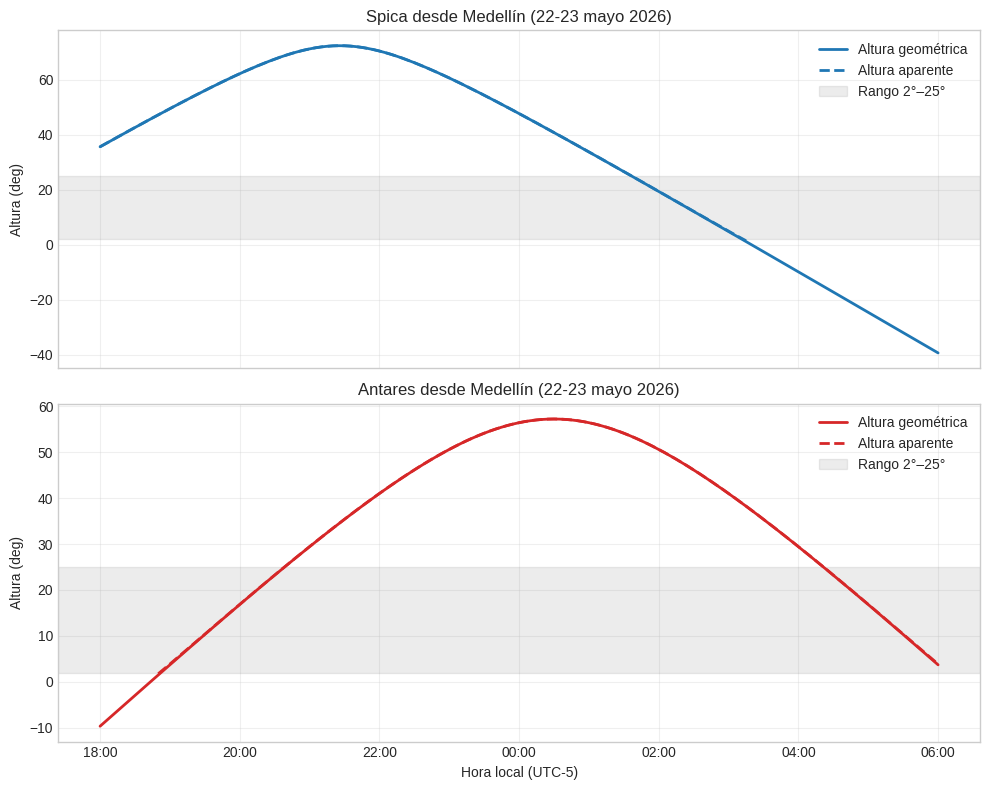

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
colores = {"Spica": "tab:blue", "Antares": "tab:red"}

for ax, estrella in zip(axes, estrellas_objetivo):
    subset = serie_total[serie_total["Estrella"] == estrella]
    ax.plot(
        subset["Tiempo local"],
        subset["Altura real (deg)"],
        color=colores[estrella],
        lw=2,
        label="Altura geométrica",
    )
    ax.plot(
        subset["Tiempo local"],
        subset["Altura aparente (deg)"],
        color=colores[estrella],
        lw=2,
        ls="--",
        label="Altura aparente",
    )
    ax.axhspan(2, 25, color="grey", alpha=0.15, label="Rango 2°–25°")
    ax.set_ylabel("Altura (deg)")
    ax.set_title(f"{estrella} desde Medellín (22-23 mayo 2026)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Hora local (UTC-5)")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

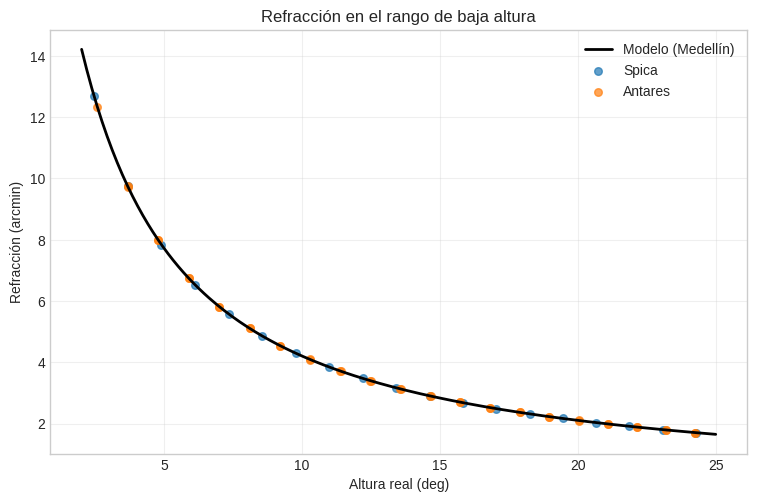

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))

h_grid = np.linspace(2, 25, 250)
R_grid = refraccion_arcmin(h_grid, P_kpa=P_kpa, T_c=T_c)
ax.plot(h_grid, R_grid, color="black", lw=2, label="Modelo (Medellín)")

for estrella in estrellas_objetivo:
    subset = serie_baja[serie_baja["Estrella"] == estrella]
    ax.scatter(
        subset["Altura real (deg)"],
        subset["Refracción (arcmin)"],
        s=30,
        alpha=0.7,
        label=estrella,
    )

ax.set_xlabel("Altura real (deg)")
ax.set_ylabel("Refracción (arcmin)")
ax.set_title("Refracción en el rango de baja altura")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

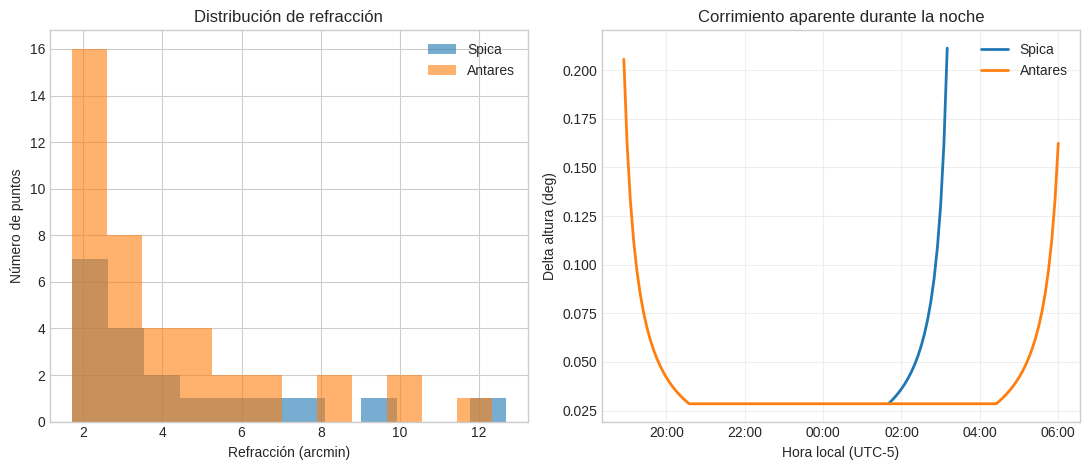

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

for estrella in estrellas_objetivo:
    subset = serie_baja[serie_baja["Estrella"] == estrella]
    axes[0].hist(
        subset["Refracción (arcmin)"],
        bins=12,
        alpha=0.6,
        label=estrella,
    )

axes[0].set_xlabel("Refracción (arcmin)")
axes[0].set_ylabel("Número de puntos")
axes[0].set_title("Distribución de refracción")
axes[0].legend()

for estrella in estrellas_objetivo:
    subset = serie_baja[serie_baja["Estrella"] == estrella]
    axes[1].plot(
        subset["Tiempo local"],
        subset["Delta altura (deg)"],
        lw=2,
        label=estrella,
    )

axes[1].set_xlabel("Hora local (UTC-5)")
axes[1].set_ylabel("Delta altura (deg)")
axes[1].set_title("Corrimiento aparente durante la noche")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretación del Experimento 1

- La refracción es máxima cuando las estrellas están entre $2^{\circ}$ y $10^{\circ}$ de altura. En ese rango el corrimiento puede superar varios minutos de arco, coherente con la teoría.
- A medida que la altura aumenta hacia $20^{\circ}$–$25^{\circ}$, la refracción cae rápidamente. Esto se observa en la nube de puntos y se superpone bien con la curva teórica del modelo para Medellín.
- Las diferencias entre estrellas no se deben a su naturaleza física, sino a **la geometría de observación**: cada una entra y sale del rango de baja altura en momentos distintos, lo que cambia la distribución temporal de los corrimientos.
- La distribución de $\Delta h$ demuestra que incluso con alturas aparentemente moderadas ($\sim 15^{\circ}$), los desplazamientos siguen siendo relevantes para observaciones de precisión.
- La metodología con astroquery permite repetir el análisis con cualquier estrella o fecha, y genera tablas verificables de entrada (posiciones, magnitudes y movimientos propios).

## 6. Comparación Barranquilla vs Medellín (pregunta 2)

Para una misma estrella baja en el horizonte, comparamos el modelo en dos condiciones realistas:

* **Barranquilla (casi nivel del mar):** $P \approx 101$ kPa, $T \approx 30$ °C
* **Medellín (montaña):** $P \approx 84$ kPa, $T \approx 18$ °C


In [15]:
h_test = np.array([5.0, 10.0, 15.0])
R_baq = refraccion_arcmin(h_test, P_kpa=101.0, T_c=30.0)
R_med = refraccion_arcmin(h_test, P_kpa=84.0, T_c=18.0)

comparacion = pd.DataFrame({
    'h (deg)': h_test,
    'R Barranquilla (arcmin)': np.round(R_baq, 2),
    'R Medellín (arcmin)': np.round(R_med, 2),
    'Diferencia BAQ-MDE (arcmin)': np.round(R_baq - R_med, 2)
})

comparacion


,h (deg),R Barranquilla (arcmin),R Medellín (arcmin),Diferencia BAQ-MDE (arcmin)
0,5.0,8.90,7.71,1.19
1,10.0,4.86,4.21,0.65
2,15.0,3.28,2.84,0.44


Se observa que, para la misma altura, Barranquilla presenta refracción algo mayor por su presión más alta. Por tanto, **no medirían exactamente la misma altura aparente**.


## 7. Respuestas a las preguntas de análisis y conclusiones

### 7.1 Tendencia de $W/h_v$ vs altura
La tendencia es decreciente hacia 1. Esto indica que la deformación vertical es máxima junto al horizonte y disminuye con la altura. En esta serie, alrededor de $12^\circ$ a $15^\circ$ el achatamiento ya es visualmente pequeño.

### 7.2 ¿Misma altura aparente en Barranquilla y Medellín?
No. De acuerdo con la ecuación, $R$ escala aproximadamente con $P$ y también depende de $T$. Como Barranquilla tiene mayor presión media, la refracción es mayor y la estrella se observará ligeramente más alta respecto a Medellín (si se ignoran diferencias de geometría por latitud/longitud).

### 7.3 Implicaciones para medición de asteroides
No es despreciable. Un error de pocos minutos de arco en posición angular puede trasladarse a incertidumbres grandes al estimar órbitas, especialmente en observaciones de seguimiento para objetos cercanos a la Tierra. La calidad del ajuste orbital depende de residuales angulares pequeños; por eso la corrección de refracción es parte estándar de la reducción astrométrica.

### 7.4 Refracción no monocromática (dispersión atmosférica)
La atmósfera es dispersiva: la luz azul (menor longitud de onda) se refracta más que la roja. Cerca del horizonte, una estrella puede mostrar un borde azulado hacia la parte más elevada y rojizo hacia la parte inferior, produciendo separación cromática vertical. Esto también afecta medidas fotométricas y astrométricas si no se usan correcciones o instrumentos adecuados.

---

## Conclusión general
La refracción atmosférica modifica tanto la **posición** como la **forma aparente** de los objetos celestes. Los datos y gráficas presentados confirman dos hechos clave: (i) la refracción crece fuertemente al aproximarse al horizonte, y (ii) la refracción diferencial deforma discos extensos como Sol/Luna. En práctica astronómica, corregir este efecto no es opcional: es indispensable para lograr mediciones confiables.
